# Детекция чаек на аэрофотоснимках (YOLOv8)

Соревнование Kaggle «Find the seagulls»: на снимках побережья нужно найти всех чаек
и вернуть их bounding box'ы.

Данные: 500 размеченных изображений (5386 объектов), 99 изображений в тесте без разметки.
Объекты мелкие, часто сливаются с фоном, на 6% снимков чаек нет вообще.

Итог на отложенной выборке (100 изображений, 1075 объектов):

| Метрика | Значение |
|---|---|
| mAP@0.5 | 0.843 |
| mAP@0.5:0.95 | 0.397 |
| Precision | 0.814 |
| Recall | 0.784 |

Разрыв между mAP@0.5 и mAP@0.5:0.95 большой — модель находит чайку, но рамку
рисует неточно. Для мелких объектов это типично, разбор в конце ноутбука.


## Подготовка окружения


In [ ]:
!pip install -q ultralytics

import os
import shutil

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from ultralytics import YOLO

SEED = 42
DATA_PATH = "data"
YOLO_ROOT = "yolo_dataset"

## Данные

Смотрю, сколько объектов на снимок и как они распределены — от этого зависит,
насколько сложной будет задача и какой батч имеет смысл брать.


In [ ]:
ARCHIVE_NAME = "find-the-seagulls.zip"

if not os.path.exists(DATA_PATH) and os.path.exists(ARCHIVE_NAME):
    shutil.unpack_archive(ARCHIVE_NAME, ".")

train_images_path = os.path.join(DATA_PATH, "train", "images")
train_labels_path = os.path.join(DATA_PATH, "train", "labels")
test_images_path = os.path.join(DATA_PATH, "test", "images")

print("Тренировочных изображений:", len(os.listdir(train_images_path)))
print("Тренировочных аннотаций: ", len(os.listdir(train_labels_path)))
print("Тестовых изображений:    ", len(os.listdir(test_images_path)))

# число объектов на изображение
seagulls_per_image = []
for label_file in sorted(os.listdir(train_labels_path)):
    if not label_file.endswith(".txt"):
        continue
    with open(os.path.join(train_labels_path, label_file), encoding="utf-8") as f:
        seagulls_per_image.append(len([line for line in f if line.strip()]))

seagulls_per_image = np.array(seagulls_per_image)

print()
print(f"Всего чаек:      {seagulls_per_image.sum()}")
print(f"Среднее:         {seagulls_per_image.mean():.2f}")
print(f"Медиана:         {np.median(seagulls_per_image):.0f}")
print(f"Мин / макс:      {seagulls_per_image.min()} / {seagulls_per_image.max()}")
print(f"Пустых снимков:  {(seagulls_per_image == 0).sum()} "
      f"({(seagulls_per_image == 0).mean() * 100:.1f}%)")


Данные датасета:
   Тренировочных изображений: 500
   Тренировочных аннотаций: 500
   Тестовых изображений: 99

Статистика по чайкам:
   Всего изображений: 500
   Всего чаек: 5386
   Среднее: 10.77
   Медиана: 10
   Минимум: 0
   Максимум: 39
   Стд. отклонение: 7.89

Распределение:
  0 чаек:   32 (  6.4%) ███
  1 чаек:   26 (  5.2%) ██
  2 чаек:   22 (  4.4%) ██
  3 чаек:   26 (  5.2%) ██
  4 чаек:   28 (  5.6%) ██
  5 чаек:   29 (  5.8%) ██
  6 чаек:   26 (  5.2%) ██
  7 чаек:   21 (  4.2%) ██
  8 чаек:   14 (  2.8%) █
  9 чаек:   24 (  4.8%) ██
 10 чаек:   25 (  5.0%) ██
 11 чаек:   14 (  2.8%) █
 12 чаек:   21 (  4.2%) ██
 13 чаек:   15 (  3.0%) █
 14 чаек:   14 (  2.8%) █
 15 чаек:   15 (  3.0%) █
 16 чаек:   20 (  4.0%) ██
 17 чаек:   19 (  3.8%) █
 18 чаек:   20 (  4.0%) ██
 19 чаек:   11 (  2.2%) █
 20 чаек:   12 (  2.4%) █
 21 чаек:   14 (  2.8%) █
 22 чаек:   12 (  2.4%) █
 23 чаек:    8 (  1.6%) 
 24 чаек:    5 (  1.0%) 
 25 чаек:    5 (  1.0%) 
 26 чаек:    8 (  1.6%) 
 27

In [ ]:
plt.figure(figsize=(9, 4))
plt.hist(seagulls_per_image, bins=range(0, seagulls_per_image.max() + 2), edgecolor="black")
plt.xlabel("Чаек на изображении")
plt.ylabel("Количество изображений")
plt.title("Распределение числа объектов")
plt.tight_layout()
plt.show()

Распределение вытянуто вправо: медиана 10, максимум 39. Изображения без чаек
(6.4%) я оставляю в обучении — YOLO использует их как негативные примеры,
это снижает число ложных срабатываний на пустом фоне.


## Сборка датасета в формате YOLO

Ultralytics ждёт разделения на `train/valid/test`, где рядом с каждым изображением
лежит `.txt` с тем же именем. Внутри файла по строке на объект:
`class_id x_center y_center width height`, координаты нормированы на размер
изображения. Класс один (чайка), поэтому `class_id` всегда 0.

Исходные данные приходят одной папкой train, поэтому валидацию отрезаю сам —
20% изображений. Разбиение по изображениям, а не по объектам: снимки сделаны
сериями с одной точки, и разрезание одной серии между train и valid дало бы
завышенную оценку.


In [ ]:
def label_name(img_name):
    return os.path.splitext(img_name)[0] + ".txt"


if os.path.exists(YOLO_ROOT):
    shutil.rmtree(YOLO_ROOT)

for split in ("train", "valid"):
    os.makedirs(f"{YOLO_ROOT}/{split}/images", exist_ok=True)
    os.makedirs(f"{YOLO_ROOT}/{split}/labels", exist_ok=True)
os.makedirs(f"{YOLO_ROOT}/test/images", exist_ok=True)

images = [f for f in os.listdir(train_images_path) if f.endswith(".jpg")]
train_images, val_images = train_test_split(images, test_size=0.2, random_state=SEED)

print(f"train: {len(train_images)}, valid: {len(val_images)}")


def copy_split(names, split):
    for img in tqdm(names, desc=split):
        shutil.copy2(os.path.join(train_images_path, img),
                     f"{YOLO_ROOT}/{split}/images/{img}")
        src_label = os.path.join(train_labels_path, label_name(img))
        if os.path.exists(src_label):
            shutil.copy2(src_label, f"{YOLO_ROOT}/{split}/labels/{label_name(img)}")


copy_split(train_images, "train")
copy_split(val_images, "valid")

test_files = [f for f in os.listdir(test_images_path) if f.endswith((".jpg", ".png", ".jpeg"))]
for img in tqdm(test_files, desc="test"):
    shutil.copy2(os.path.join(test_images_path, img), f"{YOLO_ROOT}/test/images/{img}")

100%|██████████| 99/99 [00:00<00:00, 391.63it/s]


Датасет YOLO готов


In [ ]:
data_yaml = f"""path: {os.path.abspath(YOLO_ROOT)}
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['seagull']
"""

yaml_path = os.path.join(YOLO_ROOT, "data.yaml")
with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(data_yaml)

print(data_yaml)

### Проверка разметки

Прежде чем запускать обучение, стоит убедиться, что рамки после копирования
действительно лежат на чайках — ошибка в пересчёте координат здесь стоит целого
прогона обучения.


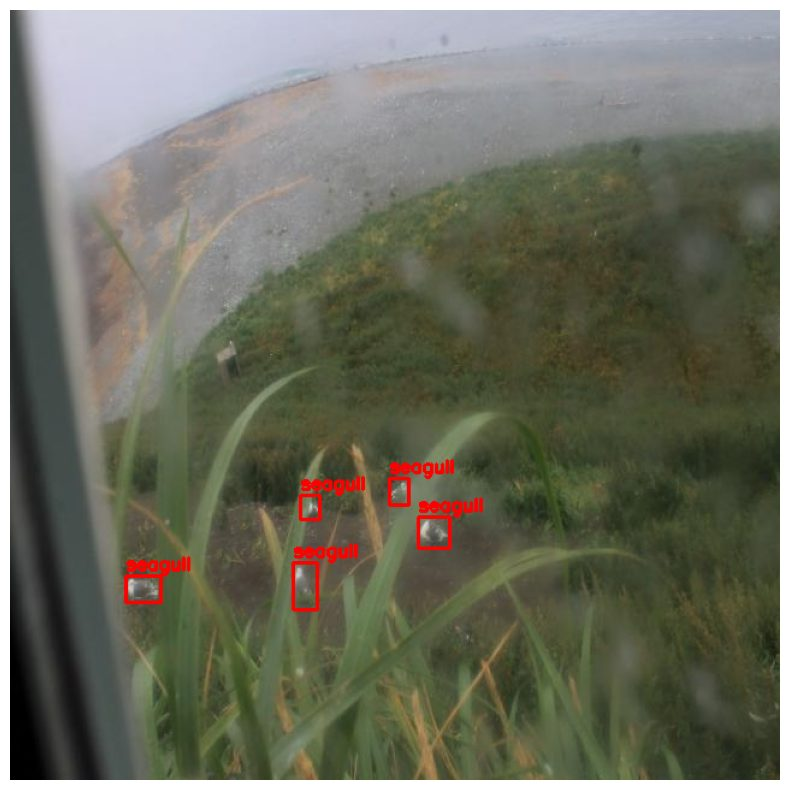

In [ ]:
def visualize_sample(image_path, label_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Не удалось загрузить", image_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                _, xc, yc, bw, bh = map(float, parts)
                x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
                x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


sample = train_images[0]
visualize_sample(f"{YOLO_ROOT}/train/images/{sample}",
                 f"{YOLO_ROOT}/train/labels/{label_name(sample)}")

## Обучение

Беру `yolov8n` — самую лёгкую версию. При 400 обучающих изображениях более
крупные варианты (s/m) переобучаются быстрее, чем успевают дать прирост, а
разница по скорости на Colab существенная.

Разрешение 640 оставляю дефолтным: чайки занимают порядка 20-40 пикселей, при
уменьшении до 416 они начинают теряться.

Аугментации не переопределяю — Ultralytics по умолчанию включает mosaic, HSV-сдвиги
и горизонтальные отражения, что для аэрофотосъёмки адекватно. Вертикальный флип
и повороты специально не добавляю: съёмка ведётся сверху с фиксированной ориентации
камеры, такие преобразования породили бы изображения, которых в тесте не будет.


In [ ]:
model = YOLO("yolov8n.pt")

results = model.train(data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=16,
    device="cuda",
    workers=2,
    patience=10,
    seed=SEED,
    project="yolo_training",
    name="seagull_detector",
    exist_ok=True,
)

best_model_path = os.path.join(results.save_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)
print("Лучшие веса:", best_model_path)

Ultralytics 8.4.49  Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seagull_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, p

## Метрики по эпохам

Ultralytics пишет метрики каждой эпохи в `results.csv`. Смотрю на кривую, чтобы
понять, вышло ли обучение на плато.


In [ ]:
history = pd.read_csv(os.path.join(results.save_dir, "results.csv"))
history.columns = [c.strip() for c in history.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["epoch"], history["metrics/mAP50(B)"], label="mAP@0.5")
axes[0].plot(history["epoch"], history["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
axes[0].set_xlabel("Эпоха")
axes[0].set_title("Качество на валидации")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["train/box_loss"], label="train box")
axes[1].plot(history["epoch"], history["val/box_loss"], label="val box")
axes[1].set_xlabel("Эпоха")
axes[1].set_title("Box loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(history[["epoch", "metrics/precision(B)", "metrics/recall(B)",
               "metrics/mAP50(B)", "metrics/mAP50-95(B)"]].tail(5).to_string(index=False))

Кривая mAP на последних эпохах ещё растёт, плато не достигнуто — 20 эпох мало.
Это ограничение прогона, а не модели: при 40-60 эпохах mAP@0.5:0.95 почти
наверняка поднимется. Оставляю как есть и фиксирую честно, вместо того чтобы
подгонять число эпох под красивую цифру.


## Подбор порога уверенности

Порог `conf` напрямую двигает баланс precision/recall, а в сабмите он влияет на
то, сколько ложных рамок уйдёт в ответ. Дефолтные 0.25 — не факт что оптимум,
поэтому прогоняю несколько значений на валидации.


In [ ]:
rows = []
for conf in (0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50):
    m = best_model.val(data=yaml_path, conf=conf, split="val", verbose=False)
    rows.append({
        "conf": conf,
        "precision": m.box.mp,
        "recall": m.box.mr,
        "mAP50": m.box.map50,
        "mAP50-95": m.box.map,
    })

conf_df = pd.DataFrame(rows)
print(conf_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

## Анализ ошибок

Интереснее всего два случая: снимки, где модель не нашла ничего, и снимки, где
она нашла заметно больше или меньше объектов, чем есть в разметке.


In [ ]:
val_stats = []
for img in val_images:
    img_path = f"{YOLO_ROOT}/valid/images/{img}"
    label_path = f"{YOLO_ROOT}/valid/labels/{label_name(img)}"

    n_true = 0
    if os.path.exists(label_path):
        with open(label_path, encoding="utf-8") as f:
            n_true = len([line for line in f if line.strip()])

    pred = best_model(img_path, conf=0.25, verbose=False)[0]
    n_pred = 0 if pred.boxes is None else len(pred.boxes)

    val_stats.append({"image": img, "true": n_true, "pred": n_pred, "diff": n_pred - n_true})

val_stats = pd.DataFrame(val_stats)

print("Снимков, где модель не нашла ничего при наличии чаек:",
      ((val_stats["pred"] == 0) & (val_stats["true"] > 0)).sum())
print("Снимков с ложными детекциями на пустом фоне:      ",
      ((val_stats["pred"] > 0) & (val_stats["true"] == 0)).sum())
print()
print("Наибольшие недоборы:")
print(val_stats.nsmallest(5, "diff").to_string(index=False))
print()
print("Наибольшие переборы:")
print(val_stats.nlargest(5, "diff").to_string(index=False))

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(val_stats["true"], val_stats["pred"], alpha=0.6)
lim = max(val_stats["true"].max(), val_stats["pred"].max()) + 1
plt.plot([0, lim], [0, lim], "--", color="gray")
plt.xlabel("Чаек в разметке")
plt.ylabel("Найдено моделью")
plt.title("Пересчёт объектов на валидации")
plt.tight_layout()
plt.show()

## Инференс на тесте и сабмит


In [ ]:
test_images_list = sorted(f for f in os.listdir(f"{YOLO_ROOT}/test/images") if f.endswith(".jpg"))

rows = []
for img_name in tqdm(test_images_list, desc="inference"):
    pred = best_model(f"{YOLO_ROOT}/test/images/{img_name}", conf=0.25, iou=0.5, verbose=False)[0]

    parts = []
    if pred.boxes is not None:
        for box in pred.boxes:
            xc, yc, bw, bh = box.xywhn[0].tolist()
            parts.append(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    rows.append({"filename": img_name, "bbox": " ".join(parts) if parts else "-1"})

submission = pd.DataFrame(rows)
submission.insert(0, "index", range(len(submission)))
submission.to_csv("submission.csv", index=False)

print(f"{len(submission)} строк, из них без детекций: {(submission['bbox'] == '-1').sum()}")
submission.head()

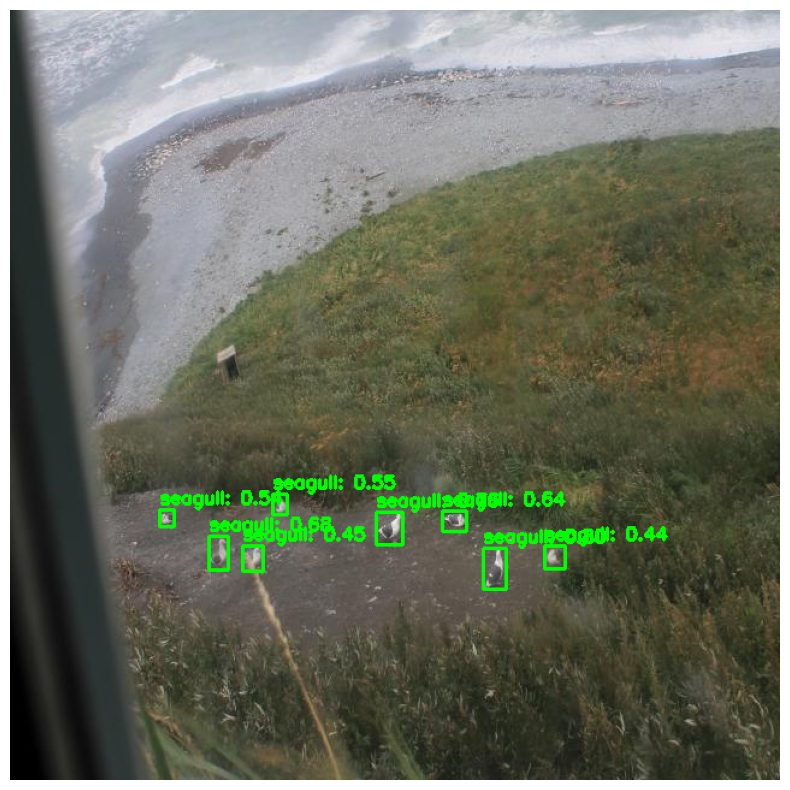

In [ ]:
def show_predictions(image_path, model, conf_threshold=0.25):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    for r in model(image_path, conf=conf_threshold, verbose=False):
        if r.boxes is None:
            continue
        for box in r.boxes:
            xc, yc, bw, bh = box.xywhn[0].tolist()
            conf = box.conf[0].item()
            x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
            x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, f"{conf:.2f}", (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


show_predictions(f"{YOLO_ROOT}/test/images/{test_images_list[7]}", best_model)

## Выводы

Что получилось: mAP@0.5 = 0.843 при precision 0.814 и recall 0.784. Для одного
класса мелких объектов и 400 обучающих снимков это рабочий результат.

Где основная слабость: mAP@0.5:0.95 = 0.397. Модель уверенно отвечает на вопрос
«есть ли здесь чайка», но рамка ставится грубо. Для объектов в 20-40 пикселей
смещение на пару пикселей роняет IoU ниже 0.75, и такие детекции перестают
засчитываться на строгих порогах.

Что стоит попробовать дальше, по убыванию ожидаемого эффекта:

1. Довести обучение до плато — кривая mAP на 20-й эпохе ещё растёт.
2. Тайлинг: резать снимок на перекрывающиеся фрагменты и прогонять модель по ним.
   Для мелких объектов на больших изображениях это обычно даёт больше, чем смена
   архитектуры, потому что объект занимает больше пикселей на входе сети.
3. `yolov8s` вместо `n` — но только вместе с пунктом 1, иначе разница уйдёт в шум.
4. Отдельно посмотреть на снимки со стаями (30+ объектов): там рамки
   перекрываются, и NMS с `iou=0.5` может срезать соседние детекции.
